<a href="https://colab.research.google.com/github/luunminte/minhluu.github.io/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. Phân tích EDA


## (1) Import thư viện, đọc dữ liệu và hiển thị dữ liệu

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set(style="whitegrid", palette="pastel")

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("loan_data_cleaned_only.csv")
df.head()

Saving loan_data_cleaned_only.csv to loan_data_cleaned_only (1).csv


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.119,829.100,11.350,19.480,737,5639.958,28854,52.100,0,0,0,0
1,1,debt_consolidation,0.136,366.860,10.373,11.630,682,4710.000,3511,25.600,1,0,0,0
2,1,credit_card,0.143,102.920,11.300,14.970,667,4066.000,4740,39.500,0,1,0,0
3,1,credit_card,0.079,125.130,11.905,16.980,727,6120.042,50807,51.000,0,0,0,0
4,1,debt_consolidation,0.150,194.020,10.714,4.000,667,3180.042,3839,76.800,0,0,1,1


## (2) Thống kê mô tả

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

desc_stats = df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
desc_stats = desc_stats.rename(columns={
    'mean': 'Trung bình',
    'median': 'Trung vị',
    'std': 'Độ lệch chuẩn',
    'min': 'Giá trị nhỏ nhất',
    'max': 'Giá trị lớn nhất'
})
desc_stats


,Trung bình,Trung vị,Độ lệch chuẩn,Giá trị nhỏ nhất,Giá trị lớn nhất
credit.policy,0.816,1.000,0.387,0.000,1.000
int.rate,0.122,0.122,0.027,0.060,0.216
installment,297.841,256.760,190.105,15.670,926.830
log.annual.inc,10.907,10.915,0.607,7.548,14.528
dti,12.738,12.830,6.847,0.000,29.960
fico,710.630,707.000,37.462,612.000,827.000
days.with.cr.line,4486.699,4140.042,2238.215,178.958,14159.958
revol.bal,15520.825,8635.000,24003.262,0.000,237551.000
revol.util,47.238,46.700,28.838,0.000,119.000
inq.last.6mths,1.550,1.000,2.149,0.000,33.000


## (3) Phân tích phân bố biến mục tiêu

,Số lượng,Tỷ lệ (%)
not.fully.paid,,
0,7282,84.478
1,1338,15.522


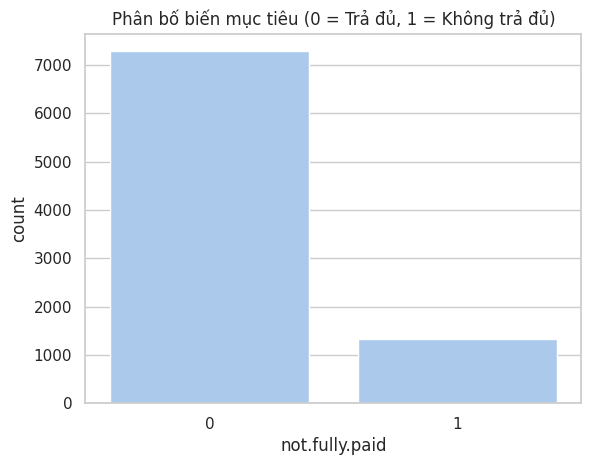

In [ ]:
target_counts = df['not.fully.paid'].value_counts()
target_ratio = df['not.fully.paid'].value_counts(normalize=True) * 100

display(pd.concat([target_counts, target_ratio], axis=1, keys=['Số lượng', 'Tỷ lệ (%)']))

sns.countplot(x='not.fully.paid', data=df)
plt.title("Phân bố biến mục tiêu (0 = Trả đủ, 1 = Không trả đủ)")
plt.show()


## (4) Phân bố các biến định lượng chính

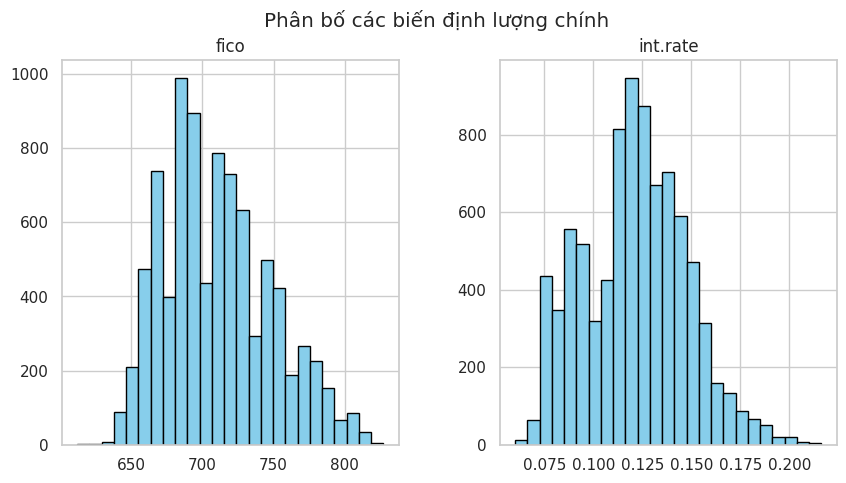

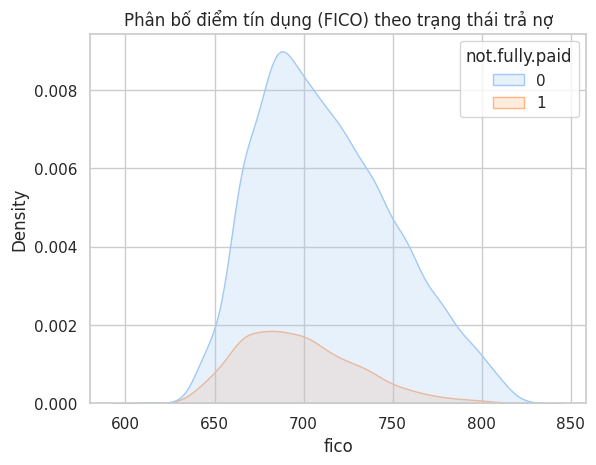

In [ ]:
num_vars = ['fico', 'int.rate']

df[num_vars].hist(figsize=(10,5), bins=25, color='skyblue', edgecolor='black')
plt.suptitle("Phân bố các biến định lượng chính")
plt.show()

sns.kdeplot(data=df, x='fico', hue='not.fully.paid', fill=True)
plt.title("Phân bố điểm tín dụng (FICO) theo trạng thái trả nợ")
plt.show()

## (5) Phân tích đặc điểm biến định tính

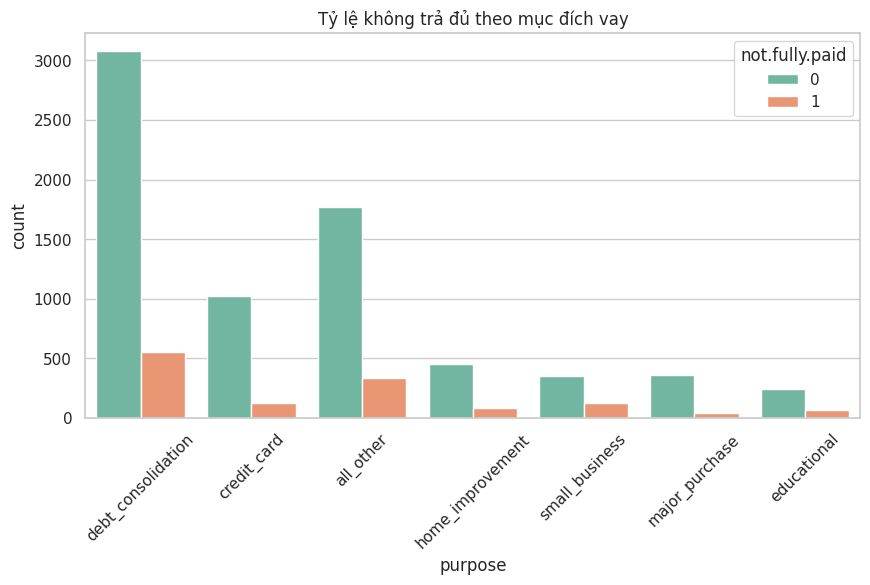

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='purpose', hue='not.fully.paid', data=df, palette='Set2')
plt.title("Tỷ lệ không trả đủ theo mục đích vay")
plt.xticks(rotation=45)
plt.show()

## (6) Phân tích mối quan hệ giữa cá biến định lượng

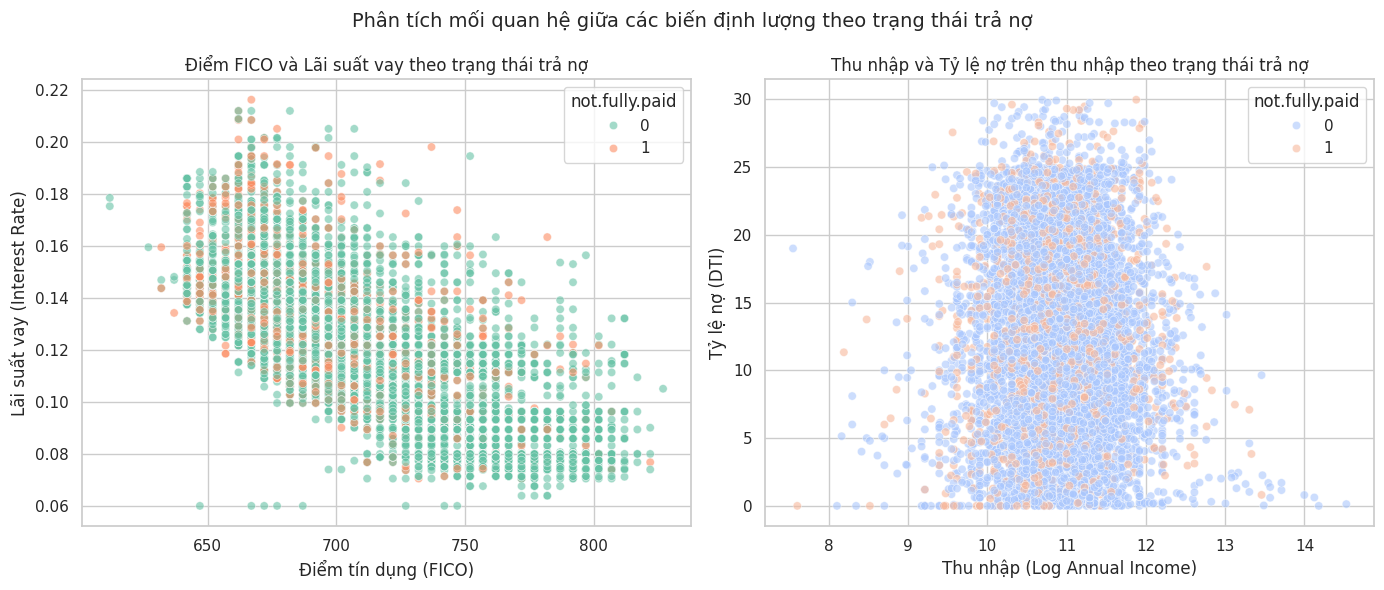

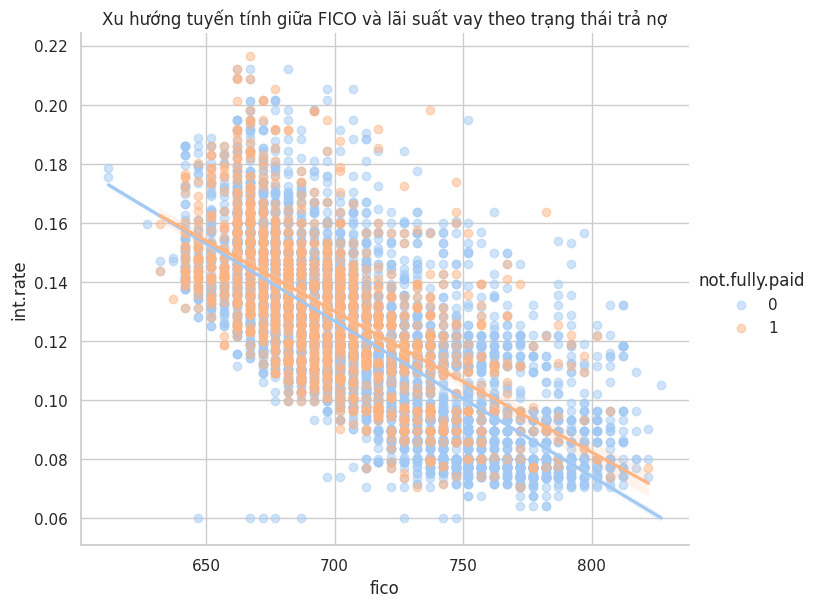

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Biểu đồ 1: FICO vs Interest Rate
sns.scatterplot(
    data=df,
    x='fico',
    y='int.rate',
    hue='not.fully.paid',
    alpha=0.6,
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title("Điểm FICO và Lãi suất vay theo trạng thái trả nợ")
axes[0].set_xlabel("Điểm tín dụng (FICO)")
axes[0].set_ylabel("Lãi suất vay (Interest Rate)")

# Biểu đồ 2: Log Annual Income vs DTI
sns.scatterplot(
    data=df,
    x='log.annual.inc',
    y='dti',
    hue='not.fully.paid',
    alpha=0.6,
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title("Thu nhập và Tỷ lệ nợ trên thu nhập theo trạng thái trả nợ")
axes[1].set_xlabel("Thu nhập (Log Annual Income)")
axes[1].set_ylabel("Tỷ lệ nợ (DTI)")

plt.suptitle("Phân tích mối quan hệ giữa các biến định lượng theo trạng thái trả nợ", fontsize=14)
plt.tight_layout()
plt.show()

# Biểu đồ 3: Xu hướng tuyến tính giữa FICO và Interest Rate
sns.lmplot(
    data=df,
    x='fico',
    y='int.rate',
    hue='not.fully.paid',
    height=6,
    aspect=1.2,
    scatter_kws={'alpha':0.5}
)
plt.title("Xu hướng tuyến tính giữa FICO và lãi suất vay theo trạng thái trả nợ")
plt.show()

## (7) Thiết lập ma trận tương quan

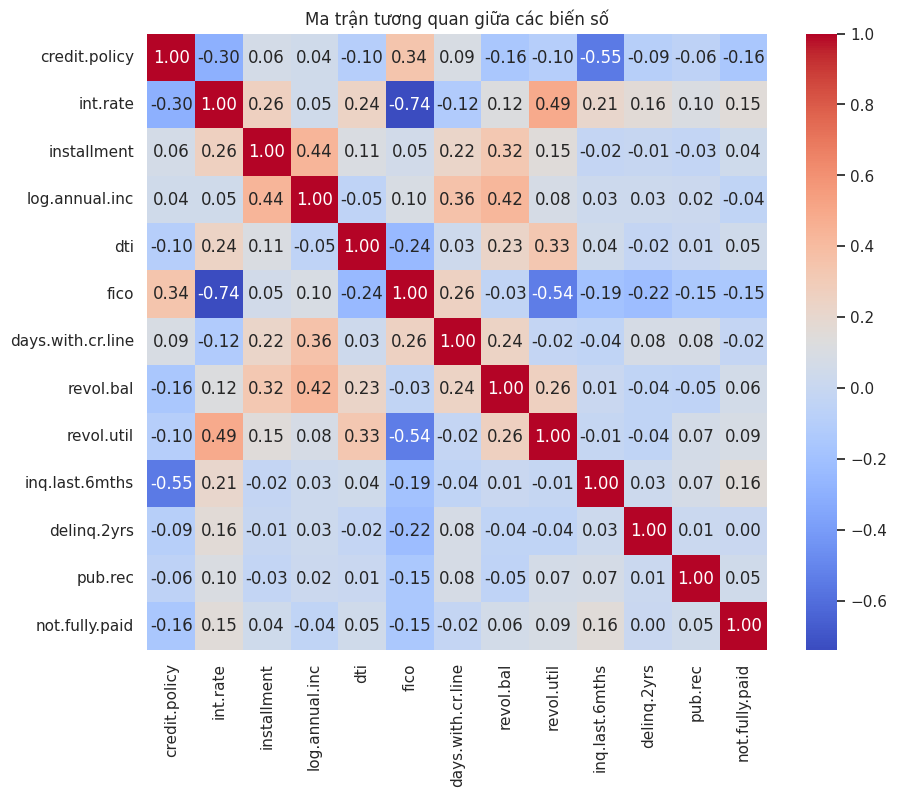

,not.fully.paid
not.fully.paid,1.000
inq.last.6mths,0.156
int.rate,0.155
revol.util,0.087
revol.bal,0.057
dti,0.048
pub.rec,0.046
installment,0.038
delinq.2yrs,0.004
days.with.cr.line,-0.022


In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

corr['not.fully.paid'].sort_values(ascending=False)


## (8) Phân tích các yếu tố ảnh hưởng đến khả năng trả nợ

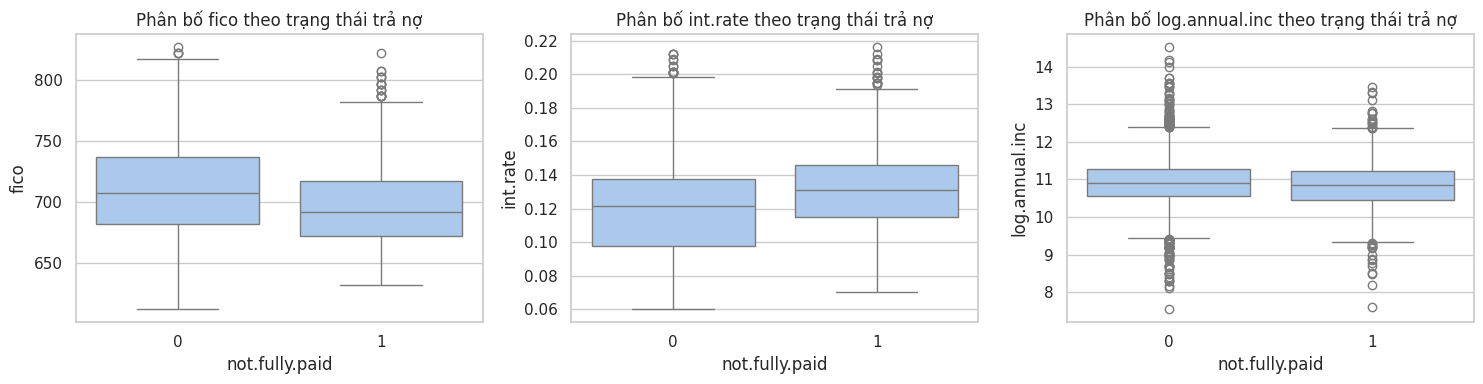

In [ ]:
plt.figure(figsize=(15,4))
for i, col in enumerate(['fico', 'int.rate', 'log.annual.inc'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='not.fully.paid', y=col, data=df)
    plt.title(f'Phân bố {col} theo trạng thái trả nợ')
plt.tight_layout()
plt.show()

,not.fully.paid
purpose,
small_business,0.266
educational,0.211
all_other,0.161
home_improvement,0.159
debt_consolidation,0.152
major_purchase,0.109
credit_card,0.109


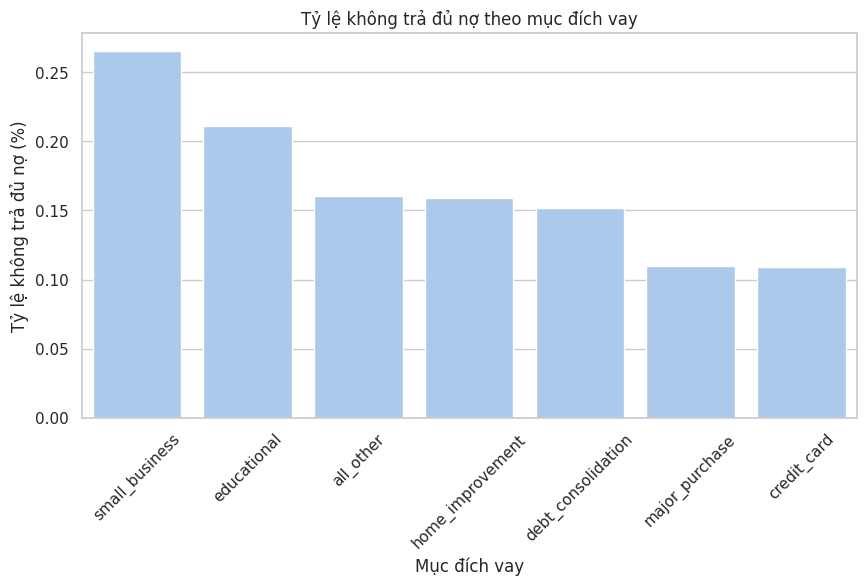

In [ ]:
purpose_risk = df.groupby('purpose')['not.fully.paid'].mean().sort_values(ascending=False)

display(purpose_risk)

plt.figure(figsize=(10,5))
sns.barplot(x=purpose_risk.index, y=purpose_risk.values)
plt.xticks(rotation=45)
plt.title("Tỷ lệ không trả đủ nợ theo mục đích vay")
plt.ylabel("Tỷ lệ không trả đủ nợ (%)")
plt.xlabel("Mục đích vay")
plt.show()